In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

Datasets = []
PREDICTORS = ["PwmD", "PwmE"]   
PHYSICAL_PREDICTORS = ["Wd", "We"]   
TARGET = ["Theta", "X", "Y"]       
TIME_STEPS = 3

for i in range(4):
    Dataset = pd.read_excel(f"./../../RotedData/Data.xlsx", f"D{i+1}")   
    # Criar as colunas de deltas automaticamente
    for var in TARGET:
        Dataset[f"Delta{var}"] = Dataset[var].shift(-1) - Dataset[var]    
           
    Datasets.append(Dataset)

for i in range(2):   
    Dataset = pd.read_csv(f"./../../Data/Data{i + 1}.csv")
        
    # Criar as colunas de deltas automaticamente
    for var in TARGET:
        Dataset[f"Delta{var}"] = Dataset[var].shift(-1) - Dataset[var]    
    
    Datasets.append(Dataset)
    

for i in range(len(Datasets)):
    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Dataset.head(5))

++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
     X    Y  Theta    Wd   We  WdRef  WeRef   PwmD   PwmE  DeltaTheta  DeltaX  \
0  0.0  0.7    0.0  0.00  0.0  -0.00   0.00  -0.00   0.00         0.0     0.0   
1  0.0  0.7    0.0  0.00  0.0   3.02   3.02  -0.00   0.00         0.0     0.0   
2  0.0  0.7    0.0  0.00  0.0   3.02   3.02  45.32  45.32         0.0     0.0   
3  0.0  0.7    0.0  0.03  0.0   3.02   3.02  45.32  45.32         0.0     0.0   
4  0.0  0.7    0.0  0.00  0.0   3.02   3.02  63.00  63.44         0.0     0.0   

   DeltaY  
0     0.0  
1     0.0  
2     0.0  
3     0.0  
4     0.0  
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
     X    Y  Theta    Wd   We  WdRef  WeRef   PwmD   PwmE  DeltaTheta  DeltaX  \
0  0.0  0.7    0.0  0.00  0.0  -0.00   0.00  -0.00   0.00         0.0     0.0   
1  0.0  0.7    0.0  0.00  0.0   3.02   3.02  -0.00   0.00         0.0     0.0   
2  0.0  0.7    0.0  0.00  0.0   3.02   3.02  45.32  45.32         0.0     0.0   
3  0.0 

In [2]:
for i in range(len(Datasets)):
    Dataset = Datasets[i].copy()

    # Criar as colunas de deltas automaticamente
    for var in TARGET:
        Dataset[f"Delta{var}"] = Dataset[var].shift(-1) - Dataset[var]

    # Dropar apenas uma vez (mantém apenas linhas onde todos os deltas existem)
    Dataset = Dataset.dropna(subset=[f"Delta{var}" for var in TARGET])

    Datasets[i] = Dataset

    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Datasets[i].tail(5))


++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
     Unnamed: 0     X     Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE  \
971       67.97  0.01  0.69   -0.8  0.0  0.0   0.85   2.03 -52.65 -29.75   
972       68.04  0.01  0.69   -0.8  0.0  0.0   0.85   2.03 -47.56 -17.83   
973       68.11  0.01  0.69   -0.8  0.0  0.0   0.85   2.03 -47.56 -17.83   
974       68.18  0.01  0.69   -0.8  0.0  0.0   0.85   2.03 -42.47  -5.67   
975       68.25  0.01  0.69   -0.8  0.0  0.0   0.85   2.03 -42.47  -5.67   

     DeltaTheta  DeltaX  DeltaY  
971         0.0     0.0     0.0  
972         0.0     0.0     0.0  
973         0.0     0.0     0.0  
974         0.0     0.0     0.0  
975         0.0     0.0     0.0  
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
     Unnamed: 0     X     Y  Theta    Wd    We  WdRef  WeRef    PwmD    PwmE  \
971       67.97  0.04  0.66  -0.78 -2.40 -1.81  -3.20  -3.17 -112.80 -122.28   
972       68.04  0.04  0.67  -0.79 -2.93 -2.43  -3.27  -3.29 -112.80 

In [3]:
NormDatasets = []
TARGET = ["DeltaTheta", "DeltaX", "DeltaY"]

SCALER = StandardScaler()
OUT_SCALER = StandardScaler()

# ===== TRAIN FASE 1 =====
Train1 = Datasets[0].copy()
Train1[PREDICTORS] = SCALER.fit_transform(Train1[PREDICTORS])
Train1[TARGET] = OUT_SCALER.fit_transform(Train1[TARGET])
NormDatasets.append(Train1)

# ===== TRAIN FASE 2 =====
Train2 = Datasets[1].copy()
Train2[PREDICTORS] = SCALER.transform(Train2[PREDICTORS])
Train2[TARGET] = OUT_SCALER.transform(Train2[TARGET])
NormDatasets.append(Train2)


for i in range(4):
      CurrentTestDataset = Datasets[i + 2]
      CurrentTestDataset[PREDICTORS] = SCALER.transform(CurrentTestDataset[PREDICTORS])
      CurrentTestDataset[TARGET] = OUT_SCALER.transform(CurrentTestDataset[TARGET])
      NormDatasets.append(CurrentTestDataset)
      print(f"++++++++++++++++++++ Dataset Normalizado {i+2} +++++++++++++++++++++++")
      print(NormDatasets[i].head(5))

++++++++++++++++++++ Dataset Normalizado 2 +++++++++++++++++++++++
   Unnamed: 0    X    Y  Theta    Wd   We  WdRef  WeRef      PwmD      PwmE  \
0        0.00  0.0  0.7   0.00  0.00  0.0   0.00   0.00  0.221564  0.111917   
1        0.07  0.0  0.7   0.00  0.00  0.0   3.28   3.28  0.221564  0.111917   
2        0.14  0.0  0.7   0.00  0.00  0.0   3.28   3.28  0.803114  0.594038   
3        0.21  0.0  0.7   0.00  0.06  0.0   3.28   3.28  0.803114  0.594038   
4        0.28  0.0  0.7   0.01  0.33  0.0   3.28   3.28  1.025343  0.786494   

   DeltaTheta    DeltaX   DeltaY  
0    0.045457 -0.001615  0.00264  
1    0.045457 -0.001615  0.00264  
2    0.045457 -0.001615  0.00264  
3    0.600031 -0.001615  0.00264  
4    0.045457 -0.001615  0.00264  
++++++++++++++++++++ Dataset Normalizado 3 +++++++++++++++++++++++
   Unnamed: 0     X     Y  Theta   Wd   We  WdRef  WeRef      PwmD      PwmE  \
0        0.00  0.01  0.69   -0.8  0.0  0.0   0.85   2.03 -0.219706  0.175547   
1        0.07  0.01  

In [4]:
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i-timesteps:i].values)
        Y_seq.append(target_data.iloc[i])
    return np.array(X_seq), np.array(Y_seq)

In [5]:
x_train1, y_train1 = CreateSequences(Train1[PREDICTORS], Train1[TARGET], TIME_STEPS)

x_train2, y_train2 = CreateSequences(Train2[PREDICTORS], Train2[TARGET], TIME_STEPS)

x_val, y_val = CreateSequences((NormDatasets[5])[PREDICTORS], (NormDatasets[5])[TARGET], TIME_STEPS)

print(f"Dimensão da entrada: {np.shape(x_train1)}")
print(f"Dimensão da saida: {np.shape(y_train1)}")

print(f"Dimensão da entrada: {np.shape(x_train2)}")
print(f"Dimensão da saida: {np.shape(y_train2)}")

print(f"Dimensão da entrada: {np.shape(x_val)}")
print(f"Dimensão da saida: {np.shape(x_val)}")

Dimensão da entrada: (973, 3, 2)
Dimensão da saida: (973, 3)
Dimensão da entrada: (973, 3, 2)
Dimensão da saida: (973, 3)
Dimensão da entrada: (1268, 3, 2)
Dimensão da saida: (1268, 3, 2)


In [6]:
x_train = np.concatenate((x_train1, x_train2), axis=0)
y_train = np.concatenate((y_train1, y_train2), axis=0)

In [7]:
print(f"Dimensão da entrada: {np.shape(x_train)}")
print(f"Dimensão da saida: {np.shape(y_train)}")

Dimensão da entrada: (1946, 3, 2)
Dimensão da saida: (1946, 3)


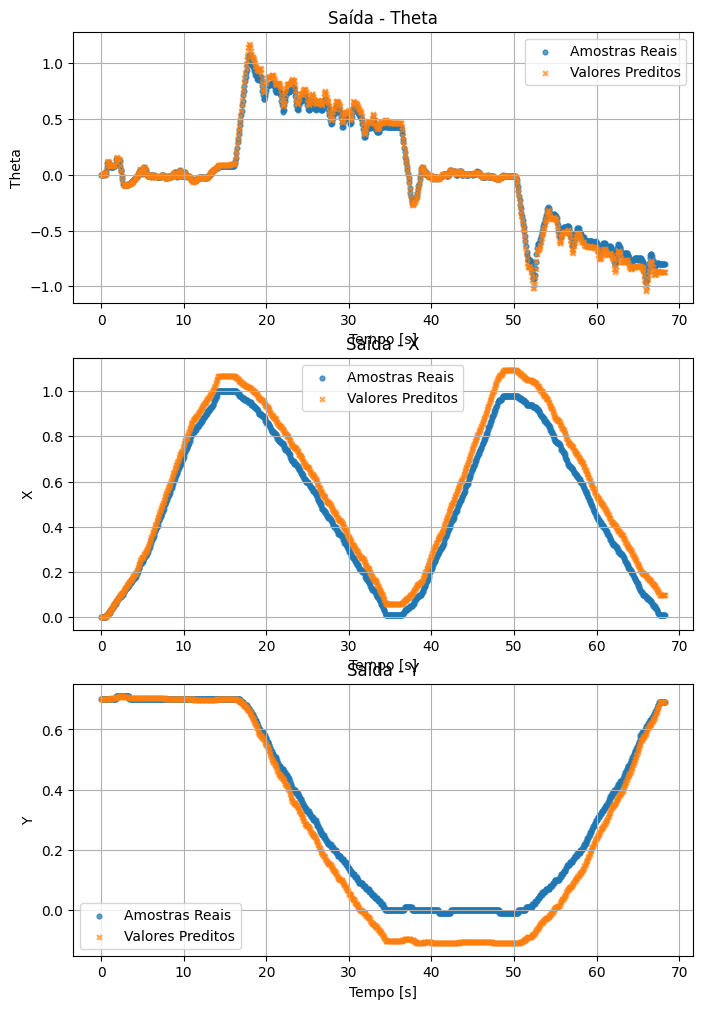

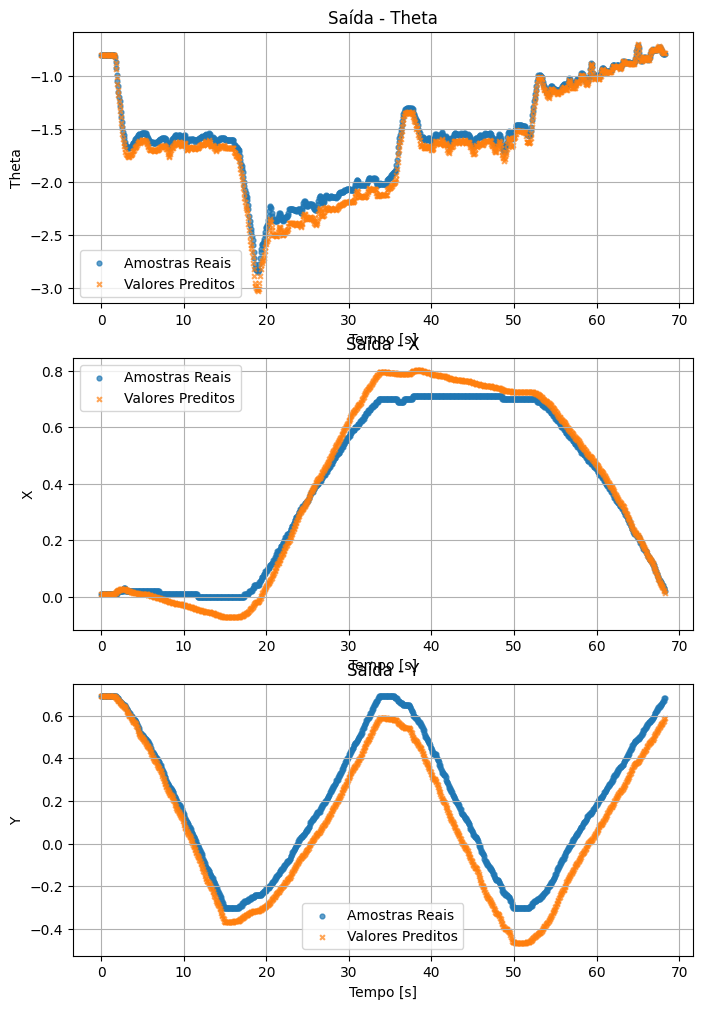

In [8]:
import matplotlib.pyplot as plt

R = 0.0341
L = 0.0606
dt = 0.07

def CinematicModel(Wd, We, theta0):
    dtheta_cin = (R/(2*L)) * (Wd - We)
    theta_cin =  theta0 + np.cumsum(dtheta_cin * dt)
    dx_cin = (R/2) * np.cos(theta_cin) * (Wd + We)
    dy_cin = (R/2) * np.sin(theta_cin) * (Wd + We)
    return [dtheta_cin, dx_cin, dy_cin]

def NumericalIntegration(Dataset, dq):
    
    init_vals = np.array([
        Dataset["Theta"].iloc[0],
        Dataset["X"].iloc[0],
        Dataset["Y"].iloc[0]
    ]) 
    
    theta_cin = init_vals[0] + np.cumsum(dq[0] * dt)
    x_cin     = init_vals[1] + np.cumsum(dq[1] * dt)
    y_cin     = init_vals[2] + np.cumsum(dq[2] * dt)
    return [theta_cin, x_cin, y_cin]
 
def PlotOut(ax, title, target_name, y_true, y_pred):
    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    ax.scatter(time, y_true, marker='o', s=12, label='Amostras Reais', alpha=0.7)
    ax.scatter(time, y_pred, marker='x', s=12, label='Valores Preditos', alpha=0.7)
    ax.set_title(f'{title} - {target_name}')
    ax.set_xlabel('Tempo [s]')
    ax.set_ylabel(target_name)
    ax.legend()
    ax.grid(True)
    
dq1 = CinematicModel(Train1["Wd"].values, Train1["We"].values, Train1["Theta"].values[0])
dq2 = CinematicModel(Train2["Wd"].values, Train2["We"].values, Train2["Theta"].values[0])

q1 = NumericalIntegration(Train1, dq1)
q2 = NumericalIntegration(Train2, dq2)

fig1, ax1 = plt.subplots(3,1, figsize=(8,12))
PlotOut(ax1[0], "Saída", "Theta", Train1["Theta"].values, q1[0])
PlotOut(ax1[1], "Saída", "X", Train1["X"].values, q1[1])
PlotOut(ax1[2], "Saída", "Y", Train1["Y"].values, q1[2])


fig2, ax2 = plt.subplots(3,1, figsize=(8,12))
PlotOut(ax2[0], "Saída", "Theta", Train2["Theta"].values, q2[0])
PlotOut(ax2[1], "Saída", "X", Train2["X"].values, q2[1])
PlotOut(ax2[2], "Saída", "Y", Train2["Y"].values, q2[2])